In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

In [2]:
from sklearn.datasets import load_sample_image

image = load_sample_image("china.jpg")

image = Image.fromarray(image).resize((396, 396))
image = np.array(image)

print("Image shape:", image.shape)

Image shape: (396, 396, 3)


In [3]:
pixels = image.reshape(-1, 3)

kmeans = KMeans(n_clusters=16, random_state=42, n_init=10)
kmeans.fit(pixels)

compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]
compressed_image = compressed_pixels.reshape(396, 396, 3).astype(np.uint8)

print("Compressed image shape:", compressed_image.shape)

Compressed image shape: (396, 396, 3)


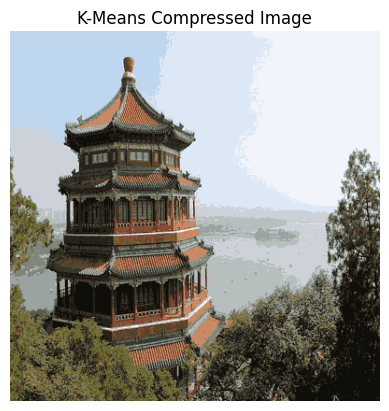

In [4]:
plt.imshow(compressed_image)
plt.axis("off")
plt.title("K-Means Compressed Image")
plt.show()

In [5]:
original_colors = np.unique(image.reshape(-1, 3), axis=0)
compressed_colors = np.unique(compressed_image.reshape(-1, 3), axis=0)

print("Original number of colors:", len(original_colors))
print("Compressed number of colors:", len(compressed_colors))
print("Number of K-Means clusters:", len(kmeans.cluster_centers_))

Original number of colors: 84709
Compressed number of colors: 16
Number of K-Means clusters: 16
